# Model V3 — AR(1) with Annual Cycle, Per-Region New Year Effect, and Full Reset

**Likelihood:**
$$y_{i,1} \sim \mathcal{N}(\mu_{i,1},\, \tau_i)$$
$$y_{i,t} \sim \mathcal{N}\!\Big(\mu_{i,t} + \phi\,(y_{i,t-1} - \mu_{i,t-1}),\, \tau_i\Big), \quad t = 2,\ldots,T$$

**Mean function:**
$$\mu_{i,t} = \alpha_i + \beta_i \cos\!\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\!\Big(\frac{2\pi t}{52}\Big) + $$ $$\delta_{\text{pre},i}\, \mathbb{1}(t\mod 52 = 0) + \delta_{\text{mid},i}\, \mathbb{1}(t\mod 52 = 1) + \delta_{\text{post},i}\, \mathbb{1}(t\mod 52 = 2) + $$ $$\sigma_{\text{pre}}\, \mathbb{1}(t = 86, i=\text{mid west}) + \sigma_{\text{mid}}\, \mathbb{1}(t = 87, i=\text{mid west}) + \sigma_{\text{post}}\, \mathbb{1}(t = 88, i=\text{mid west})$$

Where $m_i = 1$ if region $i$ is HSE Mid West, $0$ otherwise.

**Priors:**
$$\alpha_i, \beta_i, \gamma_i, \delta_{\text{pre},i}, \delta_{\text{mid},i}, \delta_{\text{post},i} \sim \mathcal{N}(0,\, 10^3) \quad \tau_i \sim \text{Gamma}(0.001,\, 0.001) \quad \phi \sim \text{Uniform}(-1,\, 1)$$
$$\sigma_{\text{pre}},\, \sigma_{\text{mid}},\, \sigma_{\text{post}} \sim \mathcal{N}(0,\, 10^3)$$

**Key difference from V2:** $\delta$ parameters are per-region ($\delta_{\cdot,i}$) rather than global ($\delta_\cdot$).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
from itertools import combinations
from pandas.core.algorithms import rank

sns.set_theme(style='whitegrid', font_scale=1.2)

# Load raw MCMC samples and observed data
df_og = pd.read_csv('../../data/wide_weekly_scaledPer10k.csv')
raw_df = pd.read_csv('../../data/models/v3/raw_samples.csv')
regions = pd.read_csv('../../data/regions.csv')['region'].tolist()

n_region = len(regions)

## Load the model parameters

In [2]:
n_weeks = df_og.shape[1] - 1  # exclude Region column

# Time vector (1-based, matching R)
t_vec = np.arange(1, n_weeks + 1)

# Event indicators (matching R model specification)
week_mod = t_vec % 52
ny_pre  = (week_mod == 0).astype(float)
ny_mid  = (week_mod == 1).astype(float)
ny_post = (week_mod == 2).astype(float)
fr_pre  = (t_vec == 86).astype(float)
fr_mid  = (t_vec == 87).astype(float)
fr_post = (t_vec == 88).astype(float)

# Mid West mask: 1 only for HSE Mid West (used by sigma/Full Reset)
mw = np.array([1.0 if r == 'HSE Mid West' else 0.0 for r in regions])

# Trig components
cos_t = np.cos(2 * np.pi * t_vec / 52)
sin_t = np.sin(2 * np.pi * t_vec / 52)

# Compute mu[i,t] from raw samples: mean and 2.5%/97.5% CIs
# V3: delta is per-region, sigma is global with mw mask
mu_mean_arr = np.zeros((n_weeks, n_region))
mu_lower_arr = np.zeros((n_weeks, n_region))
mu_upper_arr = np.zeros((n_weeks, n_region))

for i in range(n_region):
    mu_i = (raw_df[f'alpha[{i+1}]'].values[:, None]
            + raw_df[f'beta[{i+1}]'].values[:, None] * cos_t[None, :]
            + raw_df[f'gamma[{i+1}]'].values[:, None] * sin_t[None, :]
            + raw_df[f'delta_pre[{i+1}]'].values[:, None] * ny_pre[None, :]
            + raw_df[f'delta_mid[{i+1}]'].values[:, None] * ny_mid[None, :]
            + raw_df[f'delta_post[{i+1}]'].values[:, None] * ny_post[None, :]
            + raw_df['sigma_pre'].values[:, None] * (fr_pre * mw[i])[None, :]
            + raw_df['sigma_mid'].values[:, None] * (fr_mid * mw[i])[None, :]
            + raw_df['sigma_post'].values[:, None] * (fr_post * mw[i])[None, :])
    mu_mean_arr[:, i] = mu_i.mean(axis=0)
    mu_lower_arr[:, i] = np.quantile(mu_i, 0.025, axis=0)
    mu_upper_arr[:, i] = np.quantile(mu_i, 0.975, axis=0)

df_mu = pd.DataFrame(mu_mean_arr, columns=regions)
df_mu_lower = pd.DataFrame(mu_lower_arr, columns=regions)
df_mu_upper = pd.DataFrame(mu_upper_arr, columns=regions)

# Scalar parameter means
phi_mean = raw_df['phi'].mean()

# Alpha summary
df_alpha = pd.DataFrame({
    'Mean': [raw_df[f'alpha[{i+1}]'].mean() for i in range(n_region)],
    'SD': [raw_df[f'alpha[{i+1}]'].std() for i in range(n_region)],
}, index=regions)

## Preprocess
Transform the og df into regions (cols) x time (weeks)

In [3]:
df_og = df_og.T
df_og.columns = df_og.iloc[0]
df_og = df_og.drop(df_og.index[0])
df_og = df_og.reset_index(drop=True)

## Make the model estimate df
Formula
y[i,t] ~ dnorm(mu[i,t] + (phi * (y[i,t-1] - mu[i,t-1])), tau[i])

In [4]:
# Make the t-1 df
df_mu_t1 = df_mu.iloc[:df_mu.shape[0]-1]
df_og_t1 = df_og.iloc[:df_mu.shape[0]-1]
# Extract phi
phi = phi_mean
# Extract first mu
df_mu_first = pd.DataFrame([df_mu.iloc[0]])
# Extract not first mu
df_mu_rest = df_mu.iloc[1:].reset_index(drop=True)
# Calculate AR(1)
df_ar1 = df_mu_rest + (phi * (df_og_t1 - df_mu_t1))
df_ar1 = pd.concat([df_mu_first, df_ar1], ignore_index=True)
df_ar1

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,0.85951,0.579491,0.857354,2.594652,1.337241,1.699954
1,4.803402,2.910948,3.662696,7.247537,5.765024,7.971404
2,6.262887,4.453523,5.196785,7.302577,6.226491,8.198266
3,5.355901,3.20703,4.240002,5.310558,5.120285,6.25925
4,5.20583,2.628079,3.620429,5.87161,5.127017,7.538483
...,...,...,...,...,...,...
146,2.940728,1.945492,2.954412,7.257387,5.089299,6.680347
147,2.499953,1.715011,3.104676,5.630459,5.430788,5.306794
148,2.53076,1.766388,3.069474,5.124016,4.575582,5.844566
149,2.940665,1.910187,3.004729,5.482365,5.107196,5.357159


## Plot MU
This should look like yearly oscillations

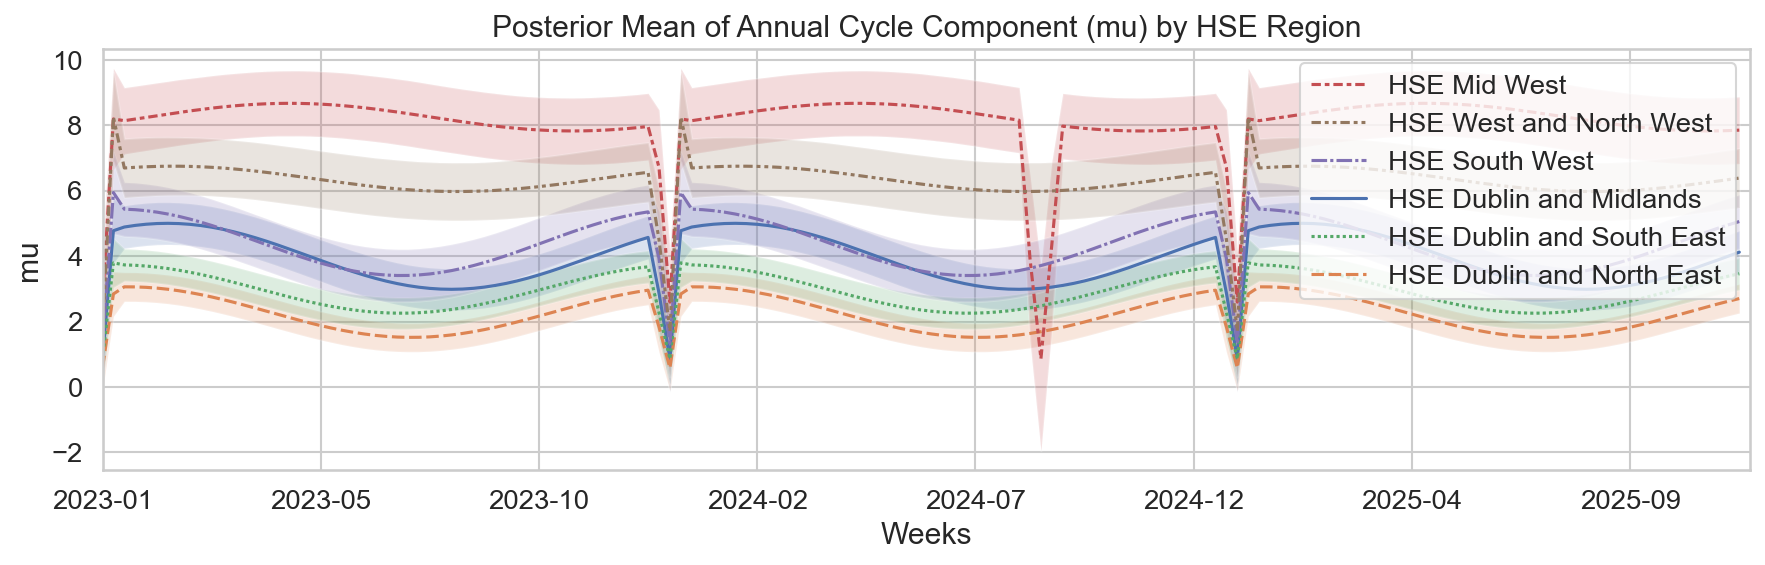

In [5]:
plt.figure(figsize=(12, 4), dpi=150)
axs = sns.lineplot(data=df_mu)
for col in df_mu.columns:
    plt.fill_between(df_mu.index, df_mu_lower[col], df_mu_upper[col], alpha=0.2)
axs.set_title('Posterior Mean of Annual Cycle Component (mu) by HSE Region')
axs.set_xlabel('Weeks')
axs.set_ylabel('mu')
axs.set_xlim(0, df_mu.shape[0])
axs.set_xticks(df_mu.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_mu.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])
handles, labels = plt.gca().get_legend_handles_labels()
order = [3,5,4,0,2,1]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
           loc='upper right')
plt.tight_layout()

## Alpha (baseline)

In [6]:
df_alpha.sort_values('Mean', ascending=False).round(2)

,Mean,SD
HSE Mid West,8.25,0.30
HSE West and North West,6.36,0.27
HSE South West,4.42,0.24
HSE Dublin and Midlands,3.99,0.19
HSE Dublin and South East,2.99,0.15
HSE Dublin and North East,2.29,0.13


## Plot Full AR1 Model

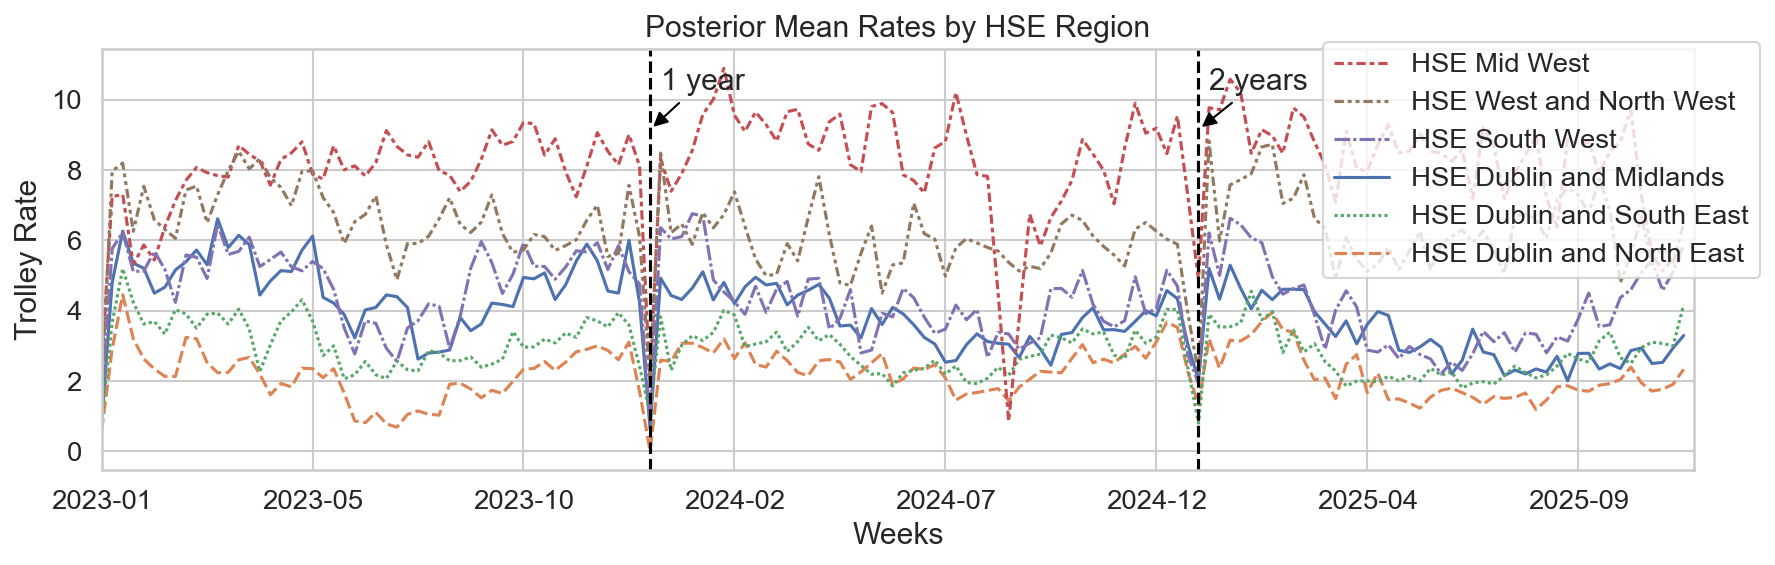

In [7]:
plt.figure(figsize=(12, 4), dpi=150)

axs = sns.lineplot(data=df_ar1)

axs.axvline(x=104, color='black', linestyle='--')
axs.axvline(x=52, color='black', linestyle='--')

axs.annotate('2 years', xy=(104, plt.ylim()[1]*0.8),
             xytext=(105, plt.ylim()[1]*.90),
             arrowprops=dict(arrowstyle='-|>', color='black'))
axs.annotate('1 year', xy=(52, plt.ylim()[1]*0.8),
             xytext=(53, plt.ylim()[1]*.90),
             arrowprops=dict(arrowstyle='-|>', color='black'))

axs.set_xlim(0, df_ar1.shape[0])
axs.set_title('Posterior Mean Rates by HSE Region')
axs.set_xlabel('Weeks')
axs.set_ylabel('Trolley Rate')

axs.set_xticks(df_ar1.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_ar1.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])

handles, labels = plt.gca().get_legend_handles_labels()
order = [3,5,4,0,2,1]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
           loc='upper right', bbox_to_anchor=(1.05, 1.05))
plt.tight_layout()

## Plot the residuals

In [8]:
df_residuals = df_og - df_ar1
df_std_resid = df_residuals / df_residuals.std()

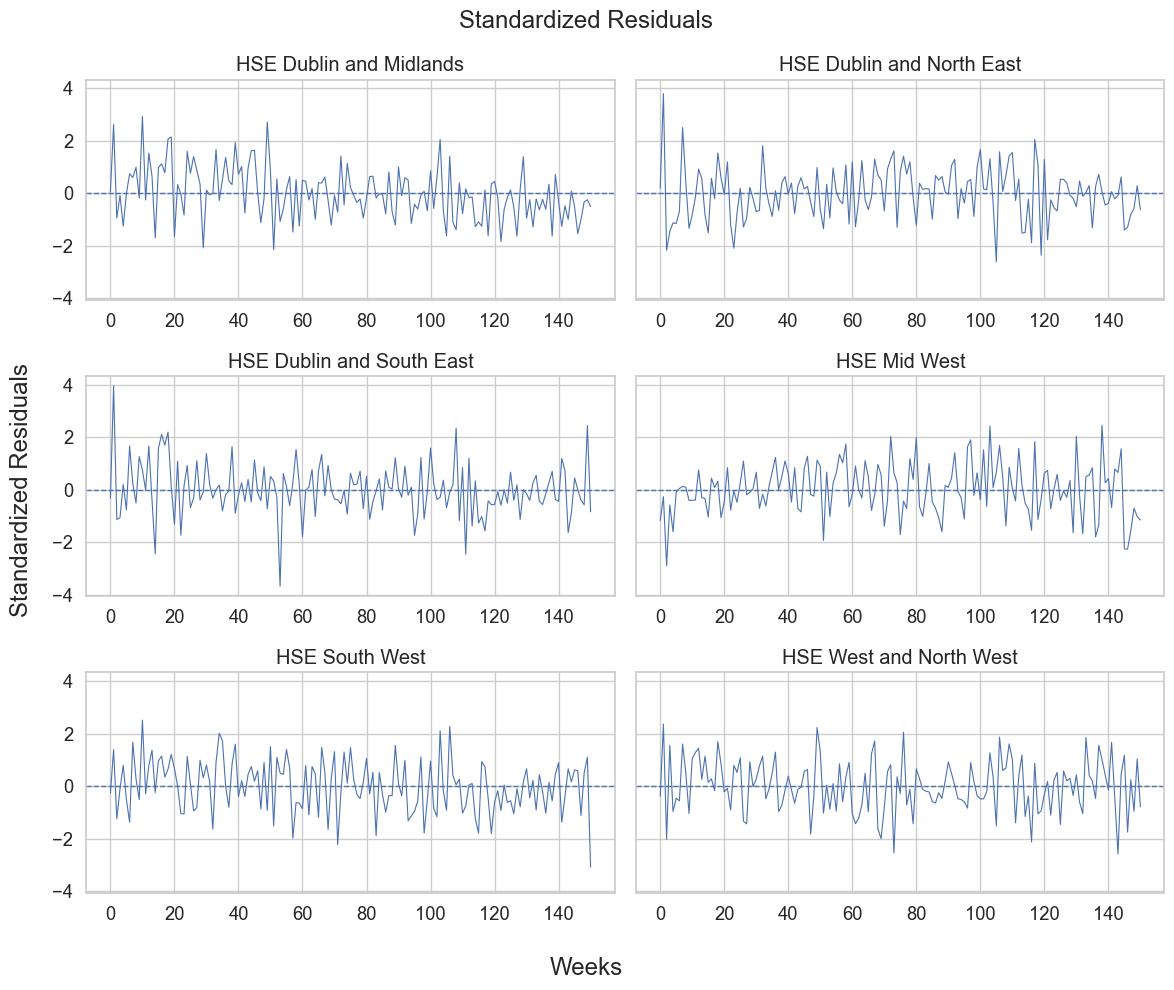

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

for col, ax in zip(df_std_resid.columns, axes.flatten()):
    ax.plot(df_std_resid[col], linewidth=0.8)
    ax.axhline(y=0, linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Standardized Residuals')
fig.supxlabel('Weeks')
fig.supylabel('Standardized Residuals')
plt.tight_layout()

### Autocorrelation of Residuals

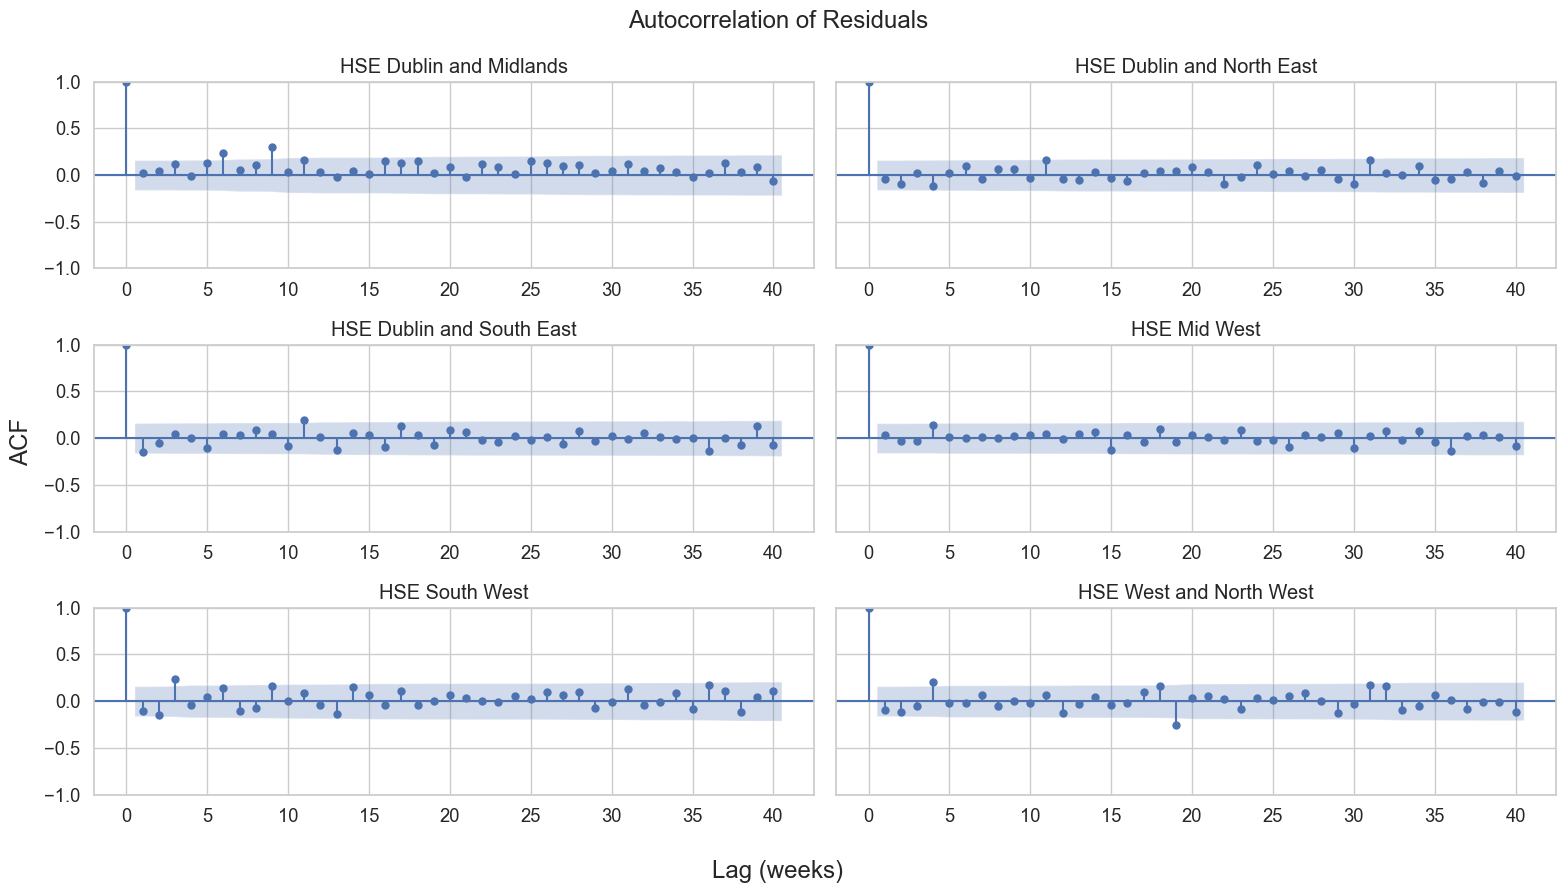

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
for ax, col in zip(axes.flatten(), df_std_resid.columns):
    plot_acf(df_std_resid[col].dropna(), ax=ax, lags=40, alpha=0.05)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Autocorrelation of Residuals')
fig.supxlabel('Lag (weeks)')
fig.supylabel('ACF')
plt.tight_layout()

### Residuals vs Fitted

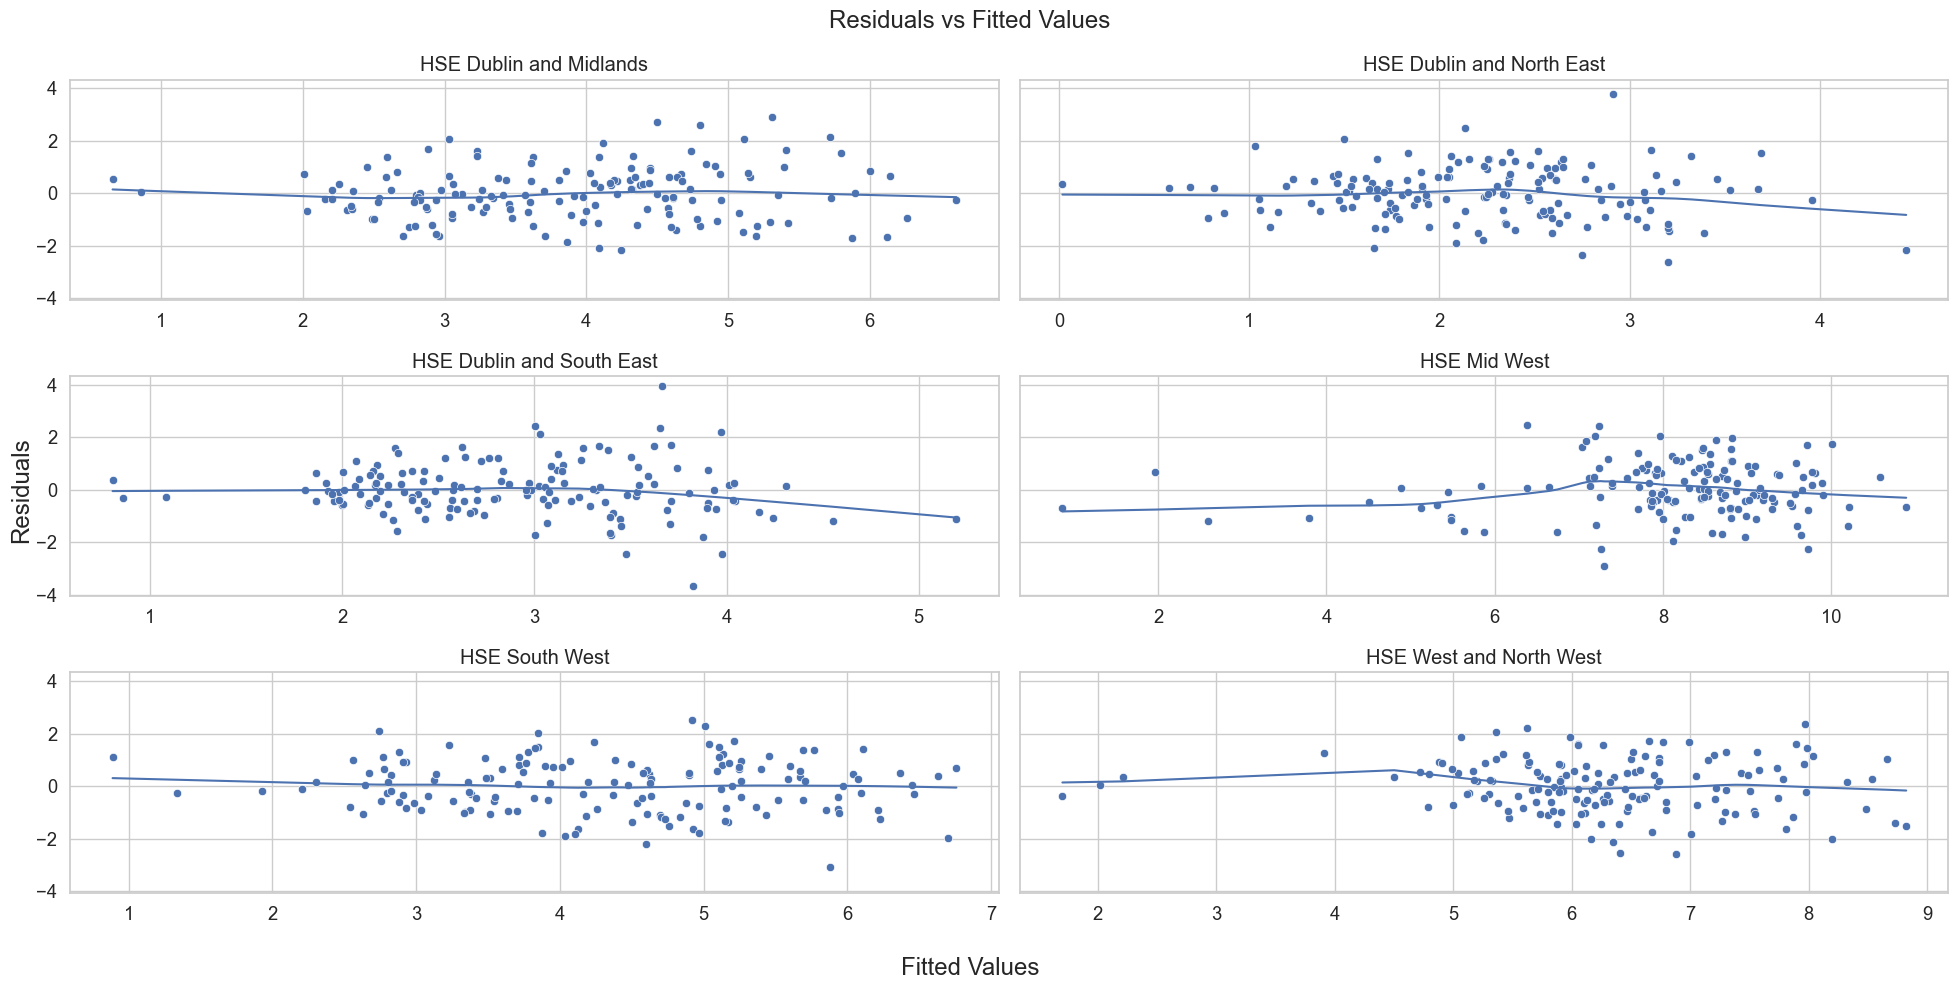

In [11]:
y_loc = .7; x_shift = 10
fig, axes = plt.subplots(3, 2, figsize=(20, 10), sharey=True)

for col, ax in zip(df_std_resid.columns, axes.flatten()):
    sns.scatterplot(x=df_ar1[col], y=df_std_resid[col], ax=ax)
    smooth = lowess(df_std_resid[col], df_ar1[col], frac=2/3, return_sorted=True)
    sns.lineplot(x=smooth[:, 0], y=smooth[:, 1], ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Residuals vs Fitted Values')
fig.supxlabel('Fitted Values')
fig.supylabel('Residuals')
plt.tight_layout()

### QQ-Plot For Residuals

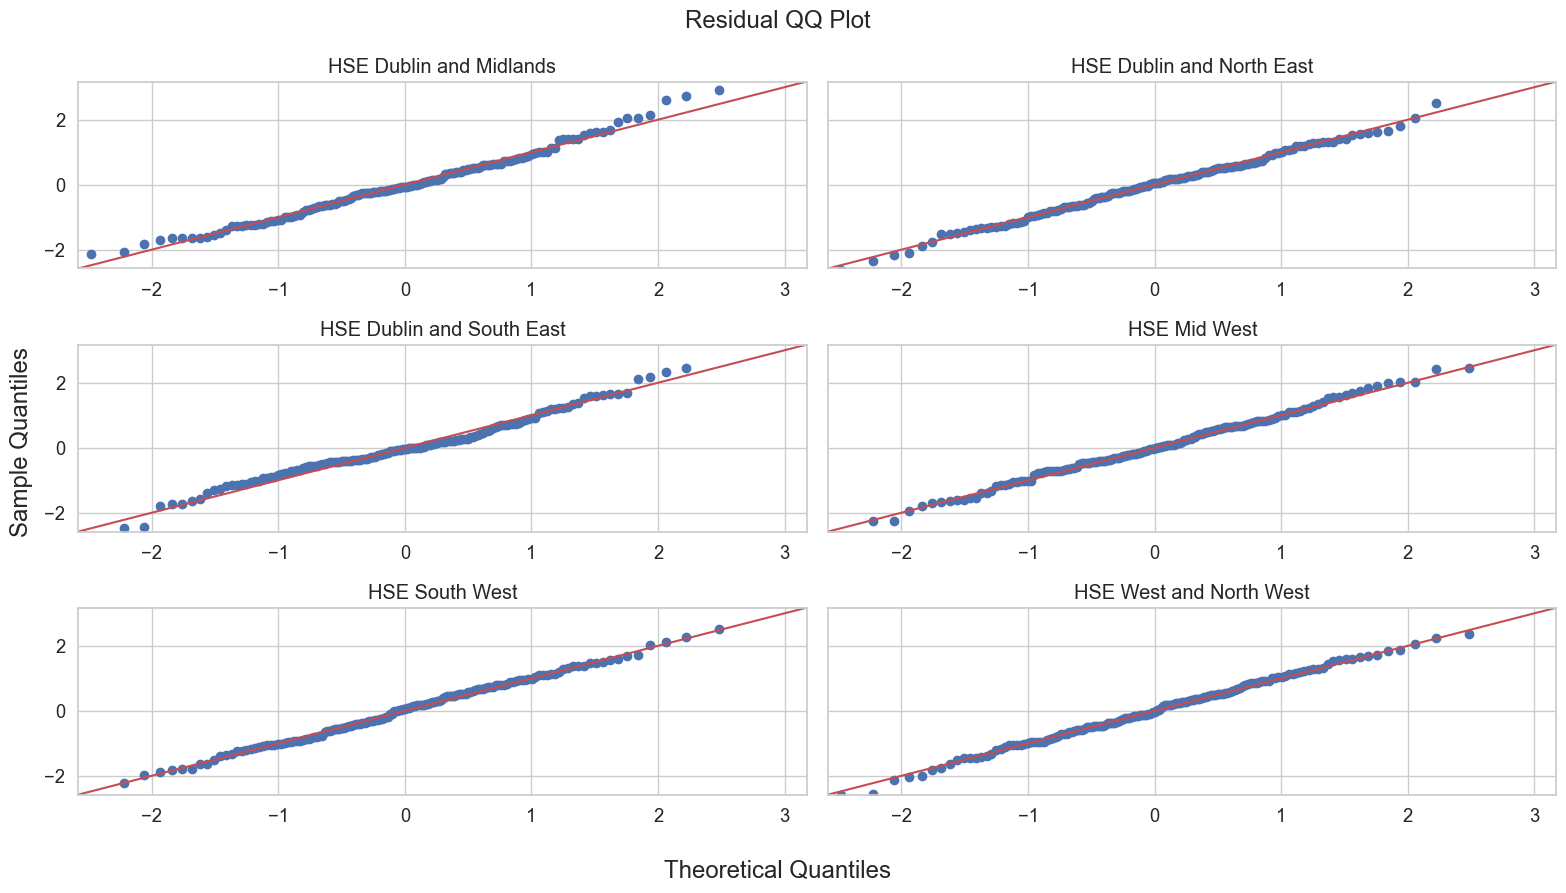

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
for i, (ax, col) in enumerate(zip(axes.flatten(), df_std_resid.columns)):
    qqplot(df_std_resid[col], line='45', ax=ax)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(col)

fig.suptitle('Residual QQ Plot')
fig.supxlabel('Theoretical Quantiles')
fig.supylabel('Sample Quantiles')
plt.tight_layout()

# Significance Testing

### Bonferroni correction

In [13]:
def calc_bonf(n_comparisons, one_sided=False):
    alpha = 0.05 / n_comparisons
    if one_sided:
        lower_q = alpha       # one-sided: full alpha in one tail
        upper_q = 1 - alpha
    else:
        lower_q = alpha / 2   # two-sided: split alpha across both tails
        upper_q = 1 - alpha / 2

    side = "one-sided" if one_sided else "two-sided"
    print(f"n_comparisons={n_comparisons}, alpha={alpha:.6f}, "
        f"lower_q={lower_q:.6f}, upper_q={upper_q:.6f} ({side})")
    return(alpha, lower_q, upper_q)

### Amplitude overall (one-sided)
$$\hat{A} = \sqrt{\beta^2 + \gamma^2}$$
$$H_0: A_i = 0 $$
$$ H_a: A_i > 0$$

In [14]:
samples = raw_df.filter(regex='beta|gamma')

ampl = {}
for i in range(n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    ampl[regions[i]] = np.sqrt(b**2 + g**2)

In [15]:
alpha, lower_q, upper_q = calc_bonf(n_region, one_sided=True)

# One-sided test: H0: A_i = 0 vs Ha: A_i > 0
# Reject if lower bound of one-sided CI > 0
results = []
for region in regions:
    ci_lower = np.quantile(ampl[region], lower_q)
    ci_upper = np.quantile(ampl[region], upper_q)
    results.append({
        'Region': region,
        'Mean': ampl[region].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 else 'No'
    })

df_ampl_overall = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
df_ampl_overall

n_comparisons=6, alpha=0.008333, lower_q=0.008333, upper_q=0.991667 (one-sided)


,Region,Mean,0.83%,99.17%,Sig
4,HSE South West,1.071,0.308,1.855,Yes
0,HSE Dublin and Midlands,1.044,0.432,1.666,Yes
1,HSE Dublin and North East,0.794,0.368,1.226,Yes
2,HSE Dublin and South East,0.766,0.304,1.241,Yes
3,HSE Mid West,0.642,0.069,1.537,Yes
5,HSE West and North West,0.575,0.061,1.363,Yes


### Amplitude pairwise

In [16]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = ampl[regions[r1]] - ampl[regions[r2]]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Region1': regions[r1],
        'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
df_ampl_pw = pd.DataFrame(results)
df_ampl_pw

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,0.250053,-0.674344,1.186984,No
1,HSE Dublin and Midlands,HSE Dublin and South East,0.277331,-0.686598,1.238338,No
2,HSE Dublin and Midlands,HSE Mid West,0.401844,-0.942101,1.471636,No
3,HSE Dublin and Midlands,HSE South West,-0.027588,-1.276232,1.159839,No
4,HSE Dublin and Midlands,HSE West and North West,0.468482,-0.770633,1.493543,No
5,HSE Dublin and North East,HSE Dublin and South East,0.027278,-0.754847,0.811887,No
6,HSE Dublin and North East,HSE Mid West,0.151792,-1.089575,1.032719,No
7,HSE Dublin and North East,HSE South West,-0.277640,-1.381592,0.780475,No
8,HSE Dublin and North East,HSE West and North West,0.218429,-0.894125,1.056384,No
9,HSE Dublin and South East,HSE Mid West,0.124513,-1.128537,1.042488,No


### Phase radians overall
$$\text{Phase} = \tan^{-1}\left(\frac{-\gamma}{\beta}\right)$$

In [17]:
alpha, lower_q, upper_q = calc_bonf(n_region)

samples = raw_df.filter(regex='beta|gamma')
phase = {}
for i in range(n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    phase[regions[i]] = np.arctan2(-g, b)

results = []
for region in regions:
    ci_lower, ci_upper = np.quantile(phase[region], [lower_q, upper_q])
    results.append({
        'Region': region,
        'Mean': phase[region].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_phase_overall = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
df_phase_overall

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


,Region,Mean,0.42%,99.58%,Sig
2,HSE Dublin and South East,-0.286,-1.095,0.524,No
4,HSE South West,-0.292,-1.369,0.770,No
1,HSE Dublin and North East,-0.402,-1.085,0.265,No
5,HSE West and North West,-0.724,-3.051,3.044,No
0,HSE Dublin and Midlands,-0.842,-1.618,-0.077,Yes
3,HSE Mid West,-1.161,-3.121,3.122,No


n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


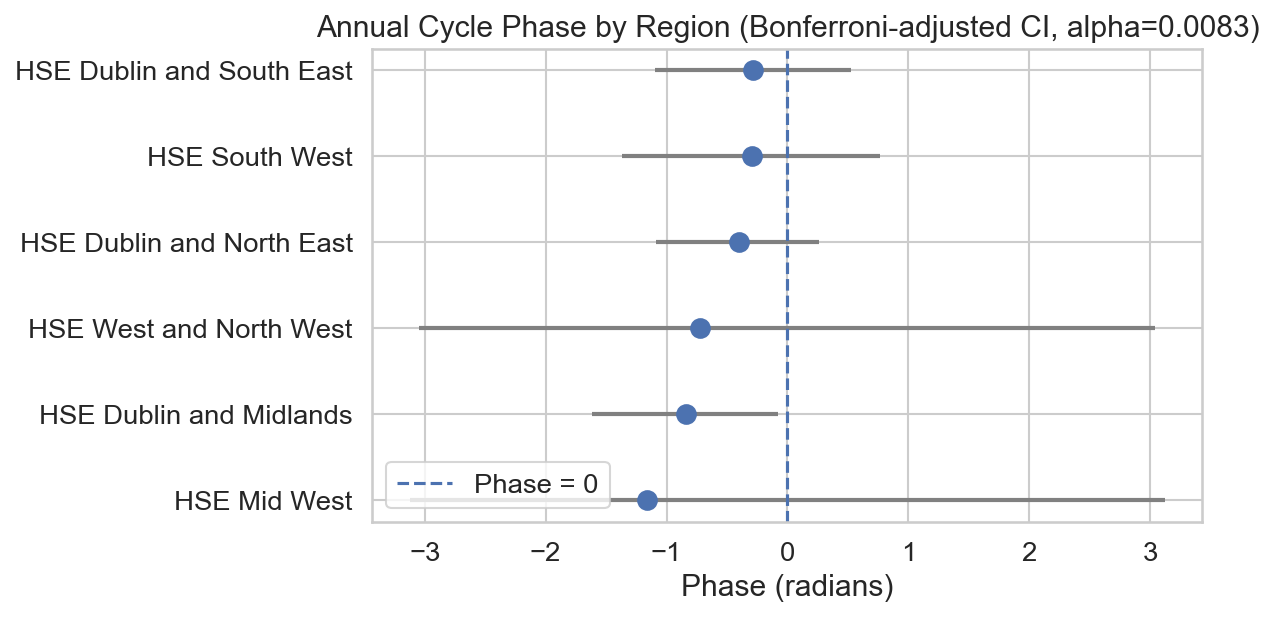

In [18]:
alpha, lower_q, upper_q = calc_bonf(n_region)

lo_col_phase = f'{lower_q*100:.2f}%'
hi_col_phase = f'{upper_q*100:.2f}%'

df_plot = df_phase_overall.sort_values('Mean')

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, layout='constrained')
y_pos = range(len(df_plot))

ax.hlines(y_pos, df_plot[lo_col_phase], df_plot[hi_col_phase],
          color='grey', linewidth=2, zorder=1)
ax.scatter(df_plot['Mean'], y_pos, s=80, zorder=2)
ax.axvline(0, linestyle='--', linewidth=1.5,
           label='Phase = 0')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Region'].values)
ax.set_xlabel('Phase (radians)')
ax.set_title(f'Annual Cycle Phase by Region (Bonferroni-adjusted CI, alpha={alpha:.4f})')
ax.legend(loc='lower left')
plt.show()

### Phase cycles overall

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


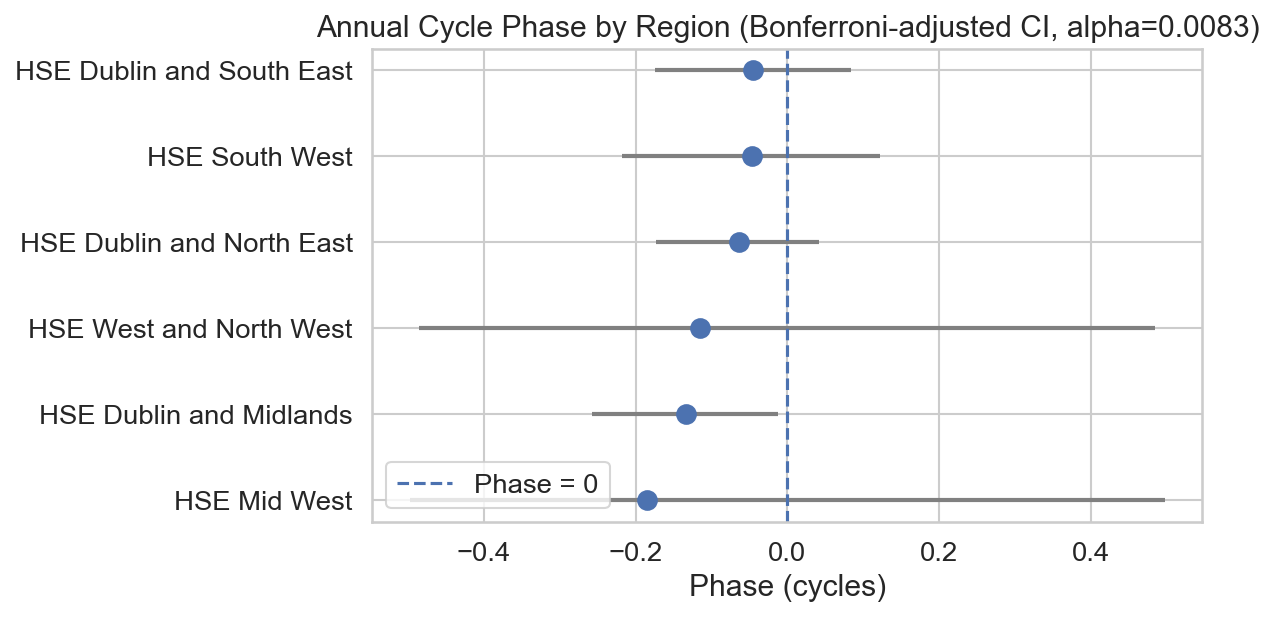

In [19]:
alpha, lower_q, upper_q = calc_bonf(n_region)

lo_col_phase = f'{lower_q*100:.2f}%'
hi_col_phase = f'{upper_q*100:.2f}%'

df_plot = df_phase_overall.copy()
df_plot.iloc[:,1:4] = df_plot.iloc[:,1:4] / (2 * np.pi)
df_plot = (df_plot.sort_values('Mean'))

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, layout='constrained')
y_pos = range(len(df_plot))

ax.hlines(y_pos, df_plot[lo_col_phase], df_plot[hi_col_phase],
          color='grey', linewidth=2, zorder=1)
ax.scatter(df_plot['Mean'], y_pos, s=80, zorder=2)
ax.axvline(0, linestyle='--', linewidth=1.5,
           label='Phase = 0')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Region'].values)
ax.set_xlabel('Phase (cycles)')
ax.set_title(f'Annual Cycle Phase by Region (Bonferroni-adjusted CI, alpha={alpha:.4f})')
ax.legend(loc='lower left')
plt.show()

### Alpha — baseline

In [20]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

alpha_samples = raw_df.filter(regex='^alpha')

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = alpha_samples[f'alpha[{r1+1}]'] - alpha_samples[f'alpha[{r2+1}]']
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Region1': regions[r1],
        'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
df_alpha_pw = pd.DataFrame(results)
df_alpha_pw

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,1.705238,1.000053,2.407247,Yes
1,HSE Dublin and Midlands,HSE Dublin and South East,0.999593,0.277273,1.729103,Yes
2,HSE Dublin and Midlands,HSE Mid West,-4.254244,-5.329102,-3.165008,Yes
3,HSE Dublin and Midlands,HSE South West,-0.427871,-1.352398,0.504220,No
4,HSE Dublin and Midlands,HSE West and North West,-2.367693,-3.359758,-1.388652,Yes
5,HSE Dublin and North East,HSE Dublin and South East,-0.705646,-1.292549,-0.116521,Yes
6,HSE Dublin and North East,HSE Mid West,-5.959482,-6.953329,-4.943474,Yes
7,HSE Dublin and North East,HSE South West,-2.133110,-2.965127,-1.306053,Yes
8,HSE Dublin and North East,HSE West and North West,-4.072931,-4.963542,-3.190982,Yes
9,HSE Dublin and South East,HSE Mid West,-5.253836,-6.255403,-4.227613,Yes


### New Year — delta (per-region in V3)
V3 fits `delta_pre[i]`, `delta_mid[i]`, `delta_post[i]` per region.

In [21]:
# Extract per-region delta samples
delta_params = ['delta_pre', 'delta_mid', 'delta_post']
delta_samples = {}  # {param: {region: array}}

for param in delta_params:
    delta_samples[param] = {}
    for i in range(n_region):
        col = f'{param}[{i+1}]'
        delta_samples[param][regions[i]] = raw_df[col].values

In [22]:
alpha, lower_q, upper_q = calc_bonf(n_region)

# Overall significance: is delta_x[i] != 0 for each region?
for param in delta_params:
    results = []
    for region in regions:
        vals = delta_samples[param][region]
        ci_lower, ci_upper = np.quantile(vals, [lower_q, upper_q])
        results.append({
            'Region': region,
            'Mean': vals.mean(),
            f'{lower_q*100:.2f}%': ci_lower,
            f'{upper_q*100:.2f}%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_sig = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
    print(f'\n=== Overall: {param} (Bonferroni, {n_region} tests) ===')
    display(df_sig)

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)

=== Overall: delta_pre (Bonferroni, 6 tests) ===


,Region,Mean,0.42%,99.58%,Sig
1,HSE Dublin and North East,-1.164,-2.135,-0.191,Yes
3,HSE Mid West,-1.290,-3.491,0.926,No
2,HSE Dublin and South East,-1.430,-2.510,-0.360,Yes
4,HSE South West,-1.460,-3.239,0.326,No
0,HSE Dublin and Midlands,-1.798,-3.217,-0.365,Yes
5,HSE West and North West,-2.095,-4.039,-0.154,Yes



=== Overall: delta_mid (Bonferroni, 6 tests) ===


,Region,Mean,0.42%,99.58%,Sig
1,HSE Dublin and North East,-2.452,-3.359,-1.528,Yes
2,HSE Dublin and South East,-2.867,-3.889,-1.850,Yes
0,HSE Dublin and Midlands,-3.893,-5.242,-2.559,Yes
4,HSE South West,-4.086,-5.794,-2.396,Yes
5,HSE West and North West,-4.936,-6.791,-3.094,Yes
3,HSE Mid West,-5.451,-7.563,-3.359,Yes



=== Overall: delta_post (Bonferroni, 6 tests) ===


,Region,Mean,0.42%,99.58%,Sig
5,HSE West and North West,1.584,-0.107,3.234,No
4,HSE South West,0.507,-1.023,2.051,No
3,HSE Mid West,0.101,-1.803,2.001,No
2,HSE Dublin and South East,0.060,-0.856,0.985,No
0,HSE Dublin and Midlands,-0.051,-1.261,1.160,No
1,HSE Dublin and North East,-0.209,-1.053,0.609,No


n_comparisons=18, alpha=0.002778, lower_q=0.001389, upper_q=0.998611 (two-sided)


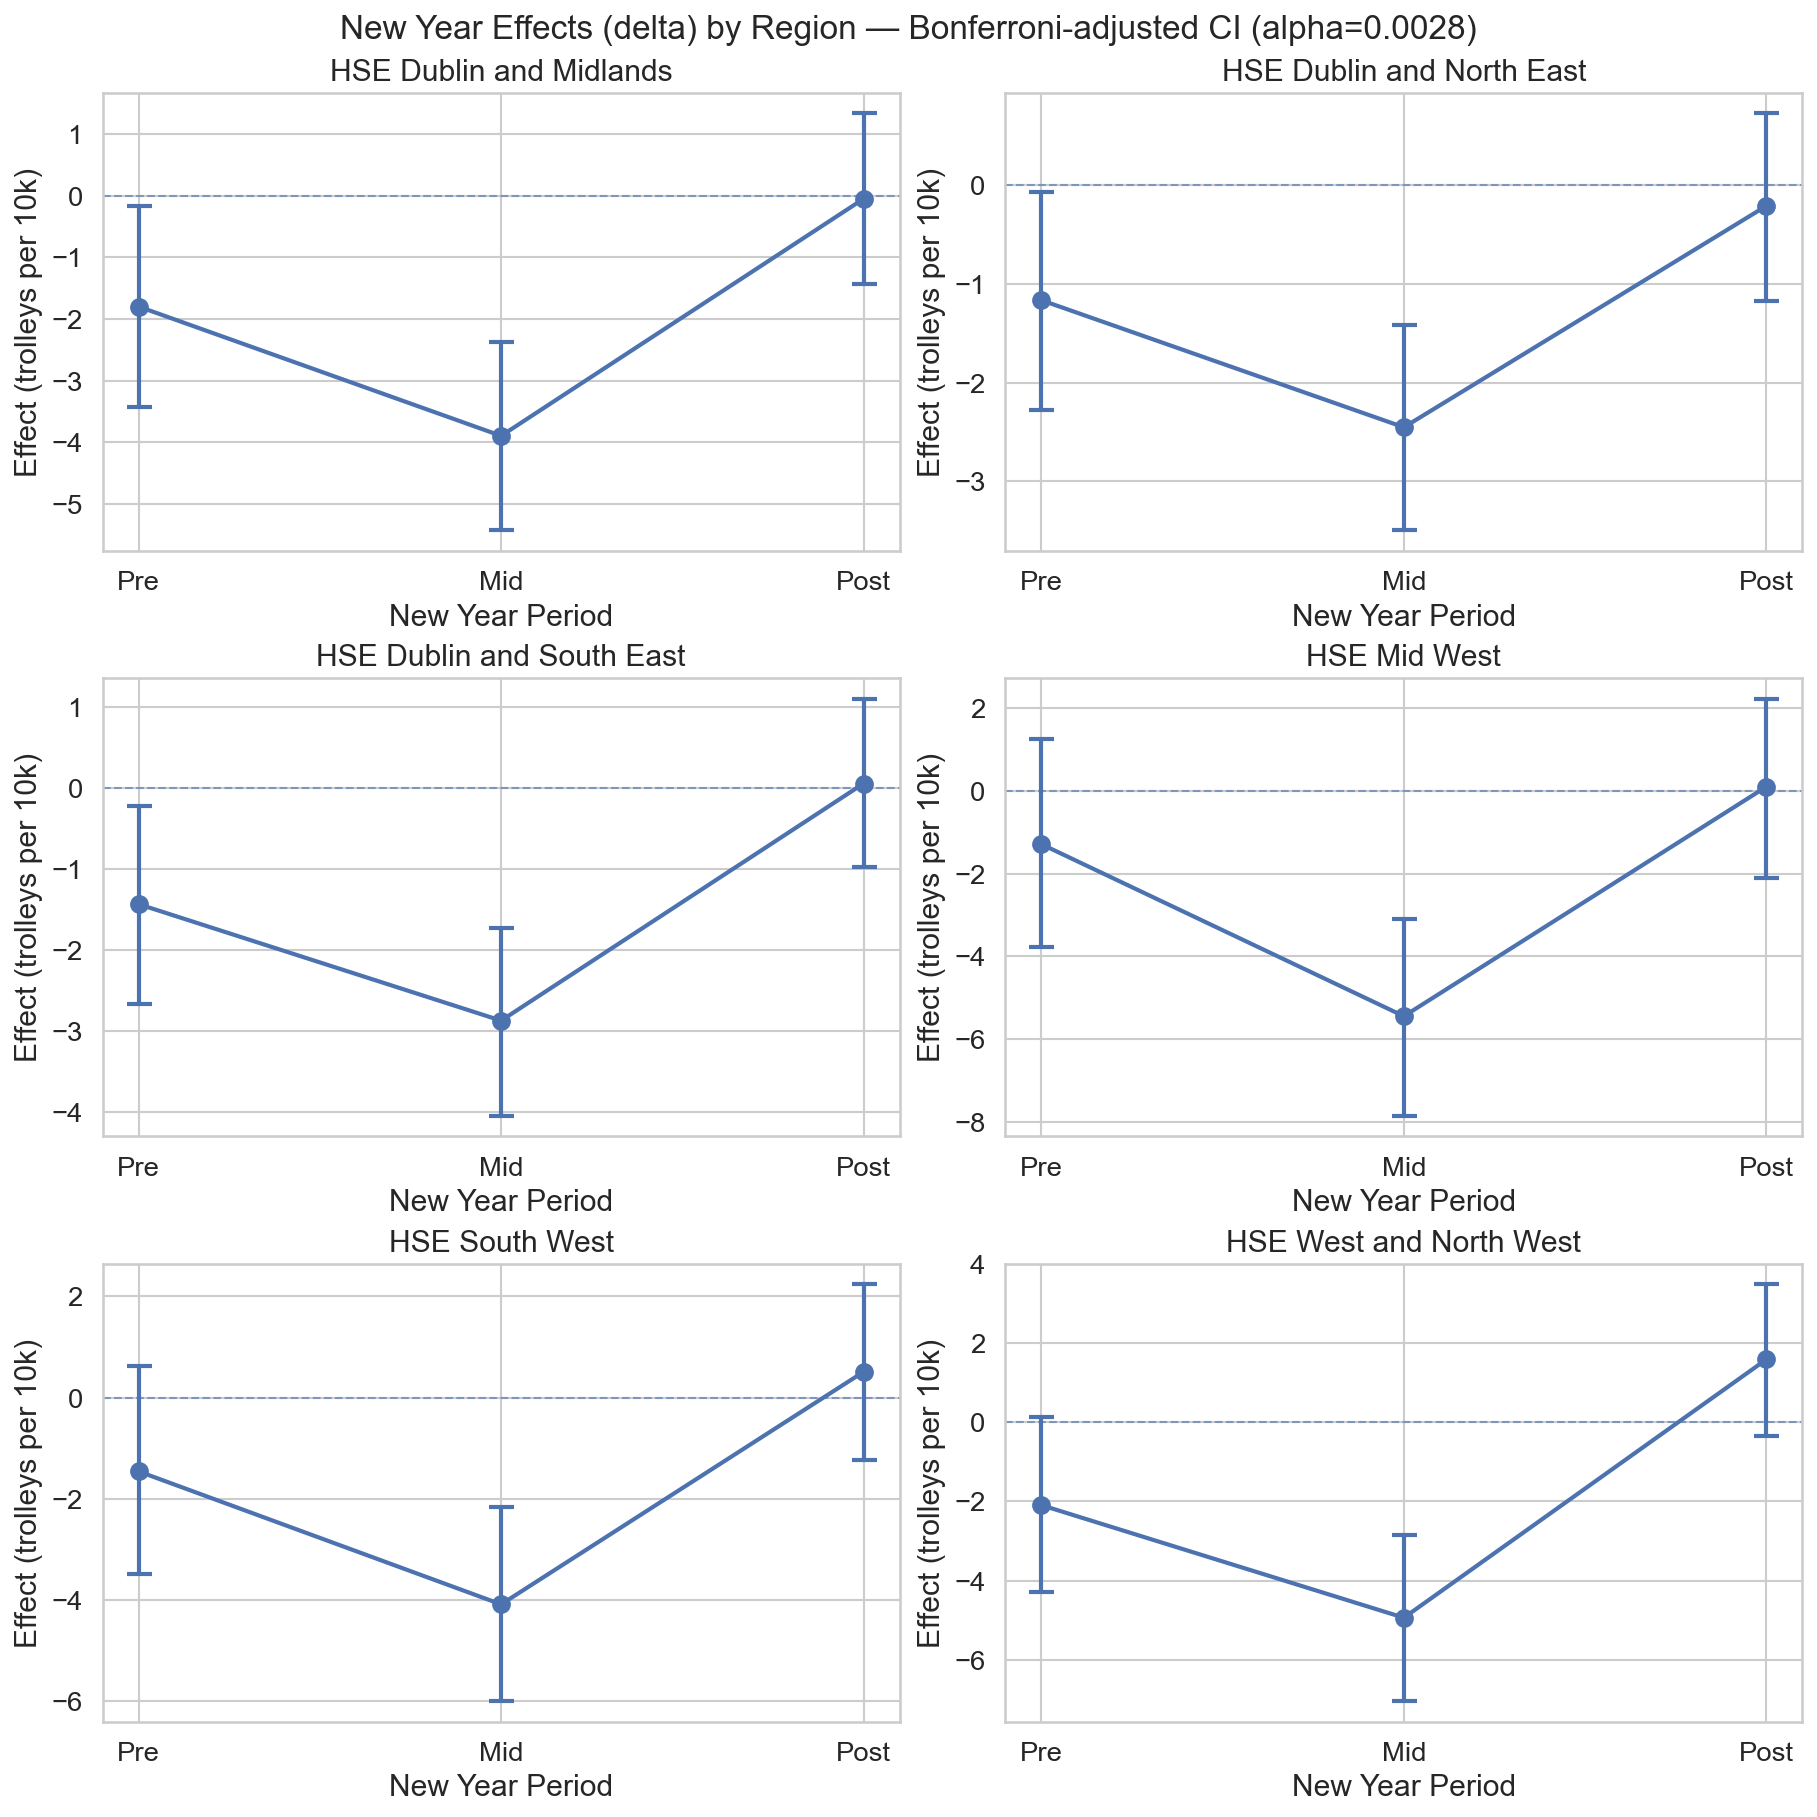

In [23]:
alpha, lower_q, upper_q = calc_bonf(n_region*3)

# New Year (delta) per-region significance — 3 rows x 2 cols, one subplot per region
labels_nice = {'delta_pre': 'Pre', 'delta_mid': 'Mid', 'delta_post': 'Post'}
x_labels = [labels_nice[p] for p in delta_params]

fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=150, layout='constrained')

for idx, (region, ax) in enumerate(zip(regions, axes.flatten())):
    means = np.array([delta_samples[p][region].mean() for p in delta_params])
    ci_lo = np.array([np.quantile(delta_samples[p][region], lower_q) for p in delta_params])
    ci_hi = np.array([np.quantile(delta_samples[p][region], upper_q) for p in delta_params])
    yerr_lower = means - ci_lo
    yerr_upper = ci_hi - means

    ax.errorbar(x_labels, means, yerr=[yerr_lower, yerr_upper],
                fmt='o-', linewidth=2, markersize=8,
                capsize=6, capthick=2, elinewidth=2, zorder=3)
    ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(region)
    ax.set_xlabel('New Year Period')
    ax.set_ylabel('Effect (trolleys per 10k)')

fig.suptitle(f'New Year Effects (delta) by Region — Bonferroni-adjusted CI (alpha={alpha:.4f})', fontsize=16)
plt.show()

### New Year — delta pairwise (per-region)

In [24]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

# Pairwise significance: delta_x[i] - delta_x[j] != 0?
for param in delta_params:
    results = []
    for r1, r2 in combinations(range(n_region), 2):
        diff = delta_samples[param][regions[r1]] - delta_samples[param][regions[r2]]
        ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
        results.append({
            'Region1': regions[r1],
            'Region2': regions[r2],
            'MeanDiff': diff.mean(),
            f'{lower_q*100:.2f}%': ci_lower,
            f'{upper_q*100:.2f}%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_pw = pd.DataFrame(results).round(3)
    print(f'\n=== Pairwise: {param} (Bonferroni, 15 tests) ===')
    display(df_pw)

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)

=== Pairwise: delta_pre (Bonferroni, 15 tests) ===


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,-0.633,-2.567,1.293,No
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.368,-2.360,1.580,No
2,HSE Dublin and Midlands,HSE Mid West,-0.508,-3.447,2.406,No
3,HSE Dublin and Midlands,HSE South West,-0.338,-2.914,2.206,No
4,HSE Dublin and Midlands,HSE West and North West,0.298,-2.427,2.989,No
5,HSE Dublin and North East,HSE Dublin and South East,0.265,-1.343,1.894,No
6,HSE Dublin and North East,HSE Mid West,0.125,-2.556,2.806,No
7,HSE Dublin and North East,HSE South West,0.295,-1.975,2.546,No
8,HSE Dublin and North East,HSE West and North West,0.931,-1.505,3.368,No
9,HSE Dublin and South East,HSE Mid West,-0.140,-2.914,2.545,No



=== Pairwise: delta_mid (Bonferroni, 15 tests) ===


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,-1.441,-3.298,0.336,No
1,HSE Dublin and Midlands,HSE Dublin and South East,-1.026,-2.897,0.833,No
2,HSE Dublin and Midlands,HSE Mid West,1.558,-1.213,4.353,No
3,HSE Dublin and Midlands,HSE South West,0.193,-2.222,2.584,No
4,HSE Dublin and Midlands,HSE West and North West,1.043,-1.443,3.555,No
5,HSE Dublin and North East,HSE Dublin and South East,0.415,-1.087,1.943,No
6,HSE Dublin and North East,HSE Mid West,2.999,0.426,5.572,Yes
7,HSE Dublin and North East,HSE South West,1.634,-0.539,3.754,No
8,HSE Dublin and North East,HSE West and North West,2.484,0.214,4.804,Yes
9,HSE Dublin and South East,HSE Mid West,2.584,0.009,5.156,Yes



=== Pairwise: delta_post (Bonferroni, 15 tests) ===


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,0.158,-1.488,1.804,No
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.111,-1.806,1.579,No
2,HSE Dublin and Midlands,HSE Mid West,-0.152,-2.637,2.348,No
3,HSE Dublin and Midlands,HSE South West,-0.558,-2.726,1.617,No
4,HSE Dublin and Midlands,HSE West and North West,-1.634,-3.907,0.655,No
5,HSE Dublin and North East,HSE Dublin and South East,-0.269,-1.648,1.109,No
6,HSE Dublin and North East,HSE Mid West,-0.310,-2.631,2.008,No
7,HSE Dublin and North East,HSE South West,-0.716,-2.626,1.218,No
8,HSE Dublin and North East,HSE West and North West,-1.792,-3.867,0.283,No
9,HSE Dublin and South East,HSE Mid West,-0.041,-2.408,2.328,No


### Full Reset — sigma (global, Mid West only)
Same as V2: `sigma_pre`, `sigma_mid`, `sigma_post` are global scalars masked by `mw[i]`.

In [25]:
alpha, lower_q, upper_q = calc_bonf(3)

# Full Reset (sigma) — global scalars, individual significance
sigma_samples_global = raw_df[['sigma_pre', 'sigma_mid', 'sigma_post']]
sigma_params = ['sigma_pre', 'sigma_mid', 'sigma_post']

results = []
for param in sigma_params:
    ci_lower, ci_upper = np.quantile(sigma_samples_global[param], [lower_q, upper_q])
    results.append({
        'Parameter': param,
        'Mean': sigma_samples_global[param].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_sigma_ind = pd.DataFrame(results).round(3)
df_sigma_ind

n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)


,Parameter,Mean,0.83%,99.17%,Sig
0,sigma_pre,-4.183,-7.110,-1.223,Yes
1,sigma_mid,-7.197,-10.548,-3.869,Yes
2,sigma_post,-3.659,-6.639,-0.693,Yes


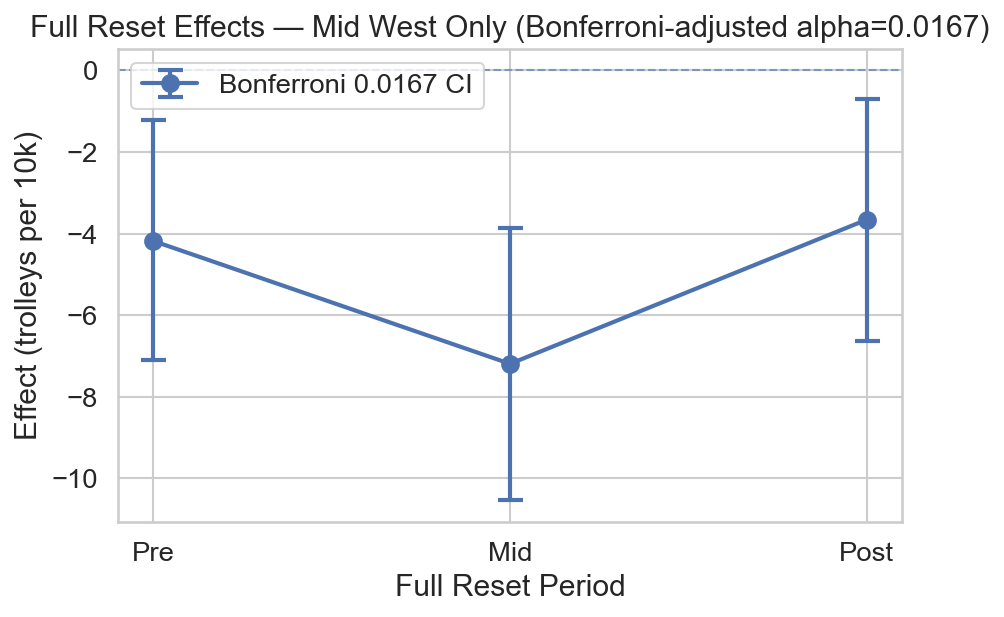

In [26]:
means = df_sigma_ind.iloc[:,1].values
yerr_lower = means - df_sigma_ind.iloc[:, 2].values
yerr_upper = df_sigma_ind.iloc[:, 3].values - means

fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(['Pre', 'Mid', 'Post'],  
            df_sigma_ind['Mean'].values, 
            yerr=[yerr_lower, yerr_upper],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3,
            label=f'Bonferroni {alpha:.4f} CI')
ax.axhline(0,  linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Full Reset Period')
ax.set_ylabel('Effect (trolleys per 10k)')
ax.set_title(f'Full Reset Effects — Mid West Only (Bonferroni-adjusted alpha={alpha:.4f})')
ax.legend()
plt.show()

In [27]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(sigma_params, 2))))

results = []
for a, b in combinations(sigma_params, 2):
    diff = sigma_samples_global[a] - sigma_samples_global[b]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Comparison': f'{a} - {b}',
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_sigma_pw = pd.DataFrame(results).round(3)
df_sigma_pw

n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)


,Comparison,MeanDiff,0.83%,99.17%,Sig
0,sigma_pre - sigma_mid,3.014,-0.091,6.113,No
1,sigma_pre - sigma_post,-0.525,-4.067,3.059,No
2,sigma_mid - sigma_post,-3.538,-6.634,-0.475,Yes


# Ranking
Pandas ranking works by default on averaging. Meaning same values ie 1, 2, 3, 3, 5 => end up as 1, 2, 2.5, 2.5 4,  5.

### Tables

In [28]:
# rank average test
pd.Series([1, 2, 3, 3, 5]).rank()

0    1.0
1    2.0
2    3.5
3    3.5
4    5.0
dtype: float64

In [29]:
# get alpha samples and rank them within each MCMC iteration
alpha_df = raw_df.filter(regex='^alpha')
alpha_df.columns = regions

ranked_alpha = alpha_df.rank(axis=1)
ranked_alpha.head(2) # sanity

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,3.0,1.0,2.0,6.0,4.0,5.0
1,3.0,1.0,2.0,6.0,4.0,5.0


In [30]:
# summarize the ranked alphas
final_ranked_df=pd.DataFrame({
    'Mean of the posterior rank':ranked_alpha.mean(axis=0),
    'Rank of the posterior rank mean':ranked_alpha.mean(axis=0).rank(),
    'Rank of the posterior rank median':ranked_alpha.median(axis=0).rank(),
    'SD':np.sqrt(ranked_alpha.var(axis=0)),
    'Max':ranked_alpha.max(axis=0),
    'Min':ranked_alpha.min(axis=0),
    '2.5%':ranked_alpha.quantile(.025),
    '97.5%':ranked_alpha.quantile(.975)
}).sort_values('Mean of the posterior rank', ascending=True).round(4)
final_ranked_df.to_csv("../../data/models/v3/ranks.csv")
final_ranked_df

,Mean of the posterior rank,Rank of the posterior rank mean,Rank of the posterior rank median,SD,Max,Min,2.5%,97.5%
HSE Dublin and North East,1.0003,1.0,1.0,0.0162,2.0,1.0,1.0,1.0
HSE Dublin and South East,1.9998,2.0,2.0,0.0166,3.0,1.0,2.0,2.0
HSE Dublin and Midlands,3.0838,3.0,3.0,0.2772,4.0,2.0,3.0,4.0
HSE South West,3.9161,4.0,4.0,0.2772,4.0,3.0,3.0,4.0
HSE West and North West,5.0000,5.0,5.0,0.0000,5.0,5.0,5.0,5.0
HSE Mid West,6.0000,6.0,6.0,0.0000,6.0,6.0,6.0,6.0


### Distributions of ranks

[1. 2. 3. 4. 5.]
[0.5 1.  1.5 2.  2.5]
[0. 1. 2. 3. 4.]
[5.  5.5 6.  6.5 7. ]
[2.5 3.  3.5 4.  4.5]
[4.  4.5 5.  5.5 6. ]


/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_98544/1607501418.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_98544/1607501418.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_98544/1607501418.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_98544/1607501418.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 

Text(0.5, 0.98, 'Distribution of Posterior Ranks for Alpha by Region')

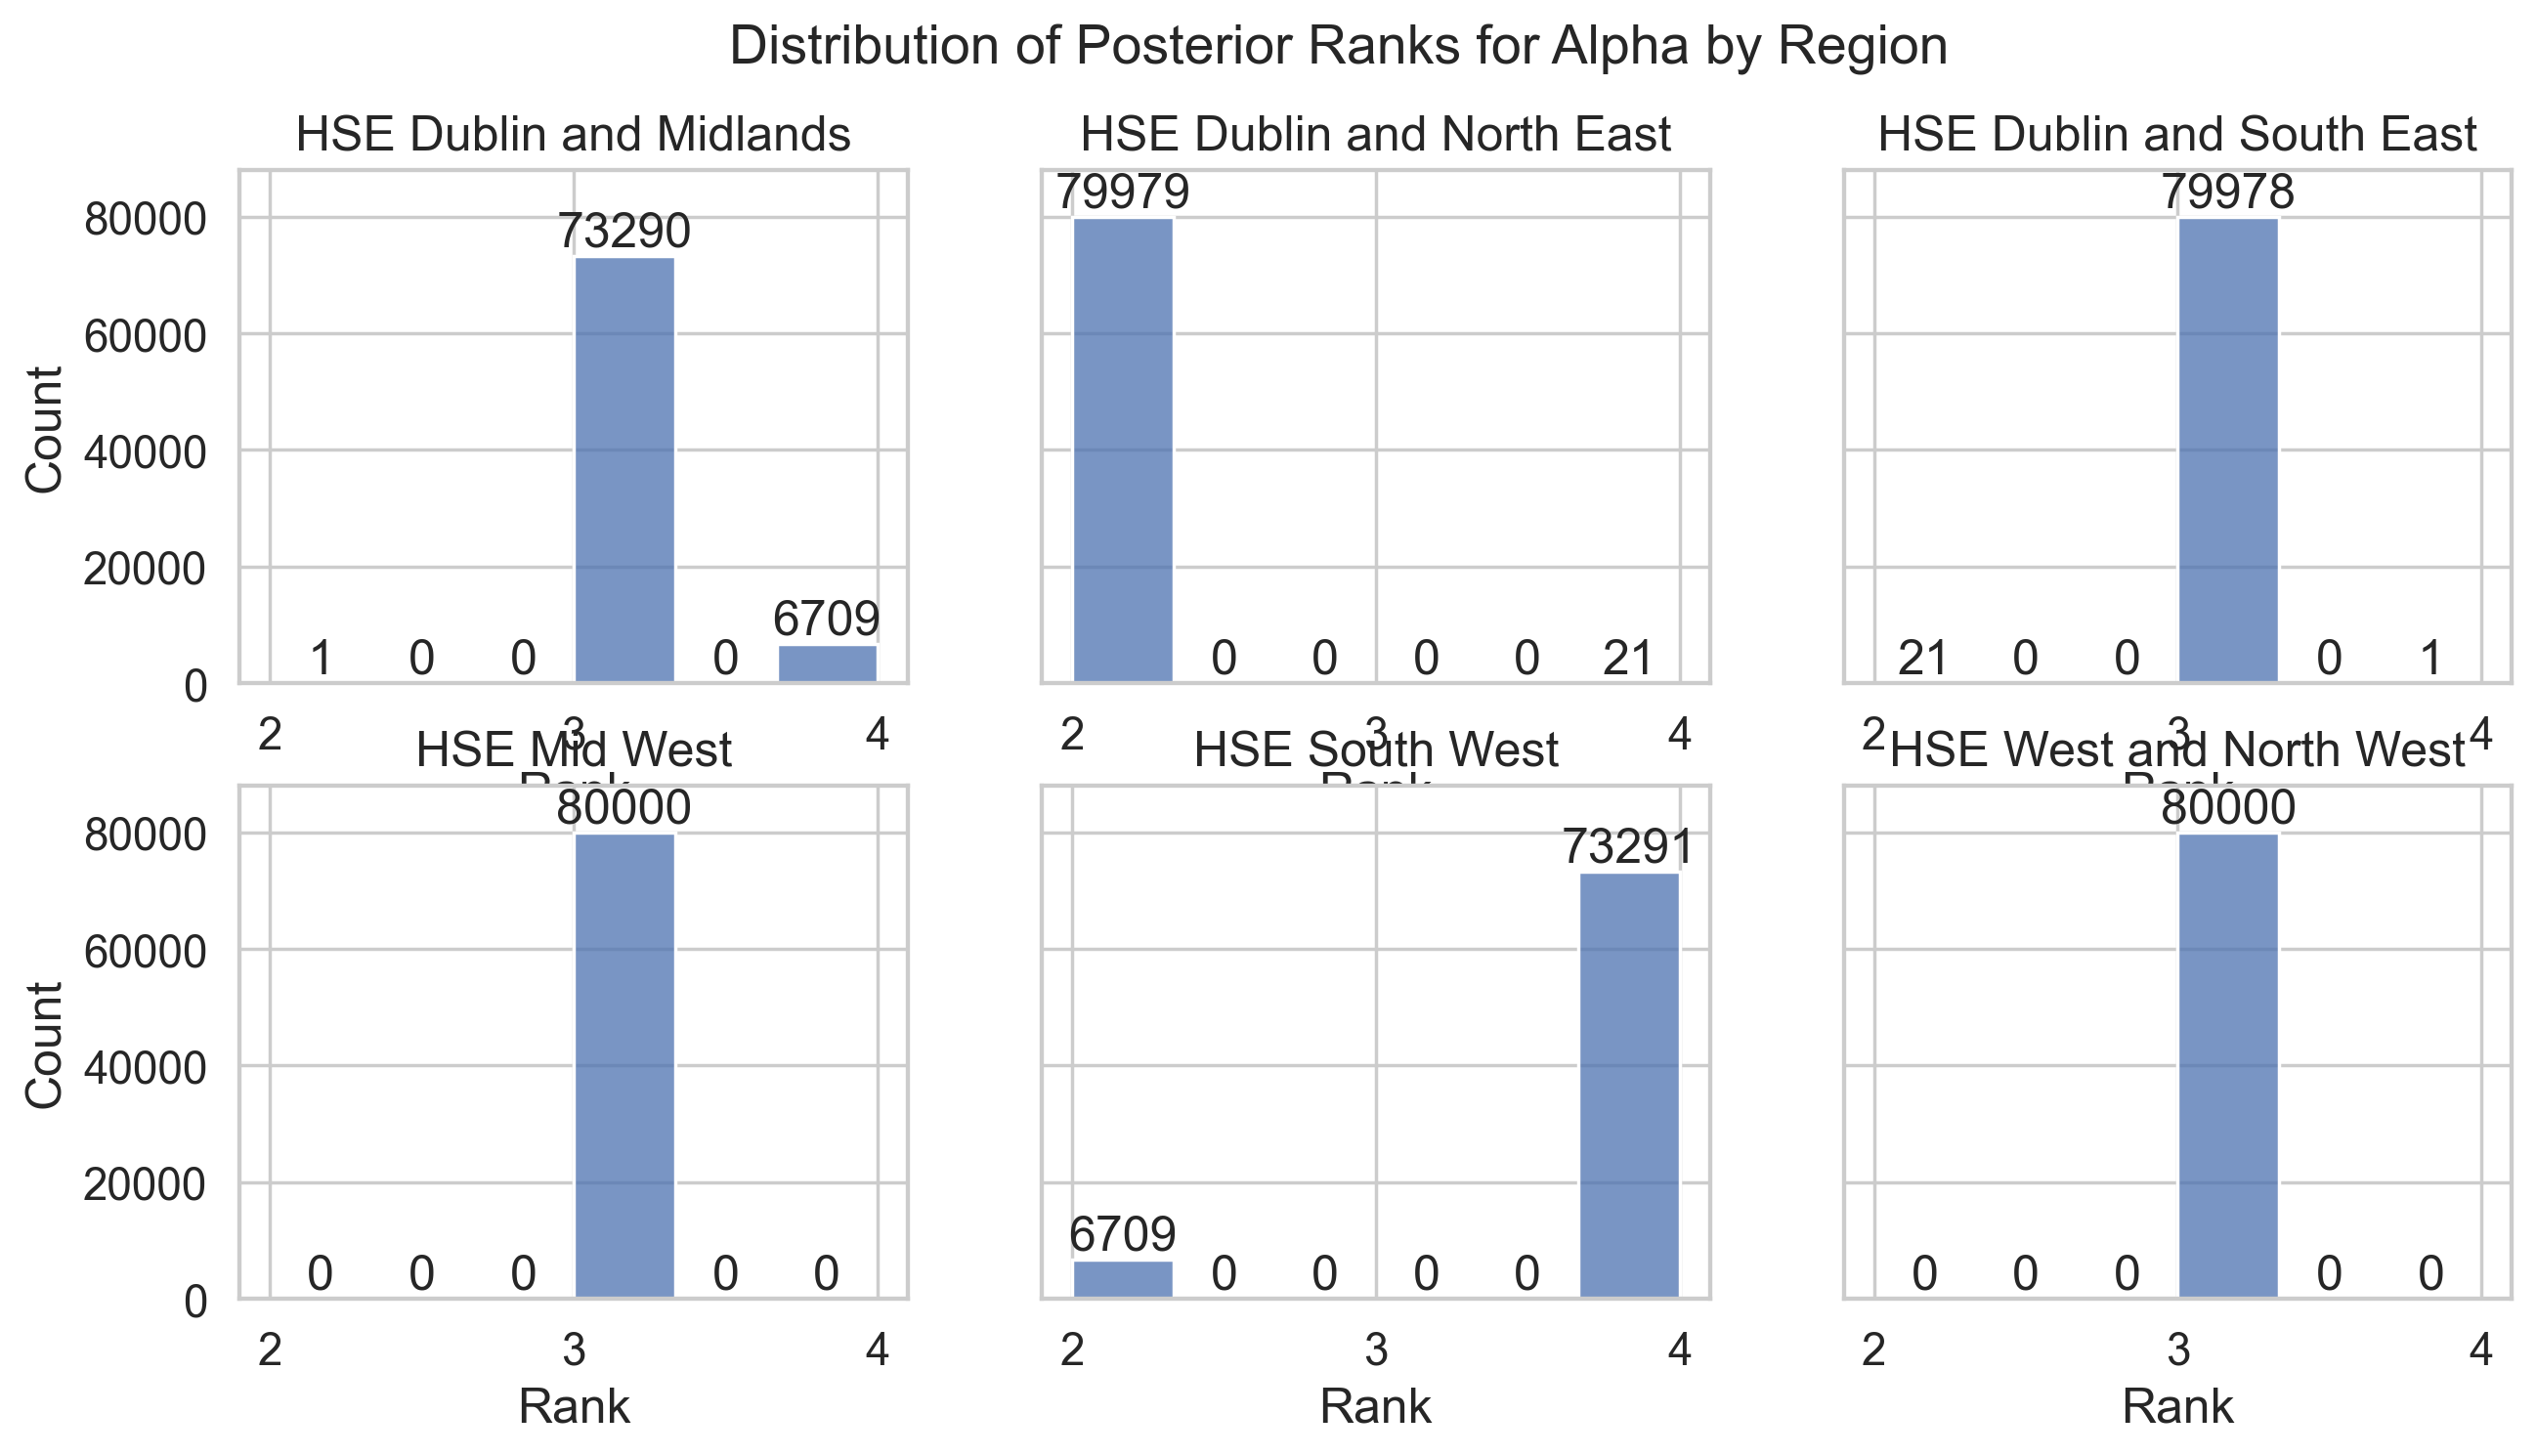

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=250, sharey=True)
for ax, col in zip(axes.flatten(), ranked_alpha.columns):
    sns.histplot(ranked_alpha[col], bins=6, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Rank')
    ax.margins(y=.1)
    # ax.set_xticks([1, 2, 3, 4, 5, 6])
    print(ax.get_xticks())
    ax.set_xticklabels([1, 2, 3, 4, 5, 6])
    # puts the counts on top of the bars
    for container in ax.containers: ax.bar_label(container)
# fig.tight_layout()
fig.suptitle('Distribution of Posterior Ranks for Alpha by Region', fontsize=16)

### Pairwise comparison

In [32]:
final_ranked_dict = final_ranked_df.to_dict()
lower_q=.025; upper_q=.975
pairwise_test_df = []
for x in combinations(regions,2):
    difference = ranked_alpha[x[0]] - ranked_alpha[x[1]]
    quantile = np.quantile(difference, [lower_q, upper_q])
    pairwise_test_df.append({
        'Region(1) - Region(2)': f"{x[0]} - {x[1]}",
        '2.5%': quantile[0],
        '97.5%': quantile[1],
        'Significant': 'Yes' if quantile[0] > 0 or quantile[1] < 0 else 'No'
    })
    # pairwise_test_df
# test if index 0 is in index 1 range
# pairwise_test_df.to_csv("../../data/models/v3/mean_rank_pairwise.csv")
pairwise_test_df = pd.DataFrame(pairwise_test_df)
pairwise_test_df.iloc[3,:]

Region(1) - Region(2)    HSE Dublin and Midlands - HSE South West
2.5%                                                         -1.0
97.5%                                                         1.0
Significant                                                    No
Name: 3, dtype: object

# Scaled With Budget

### Tables

In [33]:
# Load raw MCMC samples and observed data
raw_df = pd.read_csv('../../data/models/v3/raw_samples_scaledPerBudgetPop.csv')
regions = pd.read_csv('../../data/regions.csv')['region'].tolist()

n_region = len(regions)

In [34]:
alpha_df = raw_df.filter(regex='^alpha')
alpha_df.columns = regions
# Alpha summary
df_alpha = pd.DataFrame({
    'Mean': alpha_df.mean(axis=0),
    'SD':np.sqrt(alpha_df.var(axis=0)),
    'Max':alpha_df.max(axis=0),
    'Min':alpha_df.min(axis=0),
    '2.5%':alpha_df.quantile(.025),
    '97.5%':alpha_df.quantile(.975),
}, index=regions).round(2)
df_alpha.sort_values('Mean', ascending=True)

,Mean,SD,Max,Min,2.5%,97.5%
HSE Dublin and North East,9.50,0.55,11.94,7.11,8.42,10.58
HSE Dublin and South East,10.61,0.52,13.27,8.04,9.58,11.64
HSE Mid West,11.90,0.44,14.05,10.02,11.02,12.76
HSE South West,12.11,0.67,14.97,9.20,10.79,13.43
HSE Dublin and Midlands,12.63,0.61,15.58,9.80,11.43,13.82
HSE West and North West,14.61,0.61,17.20,12.00,13.41,15.83


In [35]:
ranked_alpha = alpha_df.rank(axis=1)

final_ranked_df=pd.DataFrame({
    'Rank mean':ranked_alpha.mean(axis=0).rank(),
    'Rank median':ranked_alpha.median(axis=0).rank(),
    'sd':np.sqrt(ranked_alpha.var(axis=0)),
    'max':ranked_alpha.max(axis=0),
    'min':ranked_alpha.min(axis=0),
    '2.5%':ranked_alpha.quantile(.025),
    '97.5%':ranked_alpha.quantile(.975),
    'count(post dist != mean rank)':ranked_alpha[ranked_alpha!=ranked_alpha.mean(axis=0).round()].count()
}).round(2)
final_ranked_df = final_ranked_df.sort_values('Rank mean', ascending=True)

### Pairwise

In [36]:
final_ranked_dict = final_ranked_df.to_dict()
pairwise_test_df = {}
# test if index 0 is in index 1 range
mean_rank_pairwise = pd.DataFrame([{
    'Average': x[0],'Interval':x[1],
    'Overlap': (final_ranked_dict['Rank mean'][x[0]] <= final_ranked_dict['97.5%'][x[1]]) \
        and\
    (final_ranked_dict['Rank mean'][x[0]] >= final_ranked_dict['2.5%'][x[1]])}
        for x in combinations(regions,2)
])
mean_rank_pairwise

,Average,Interval,Overlap
0,HSE Dublin and Midlands,HSE Dublin and North East,False
1,HSE Dublin and Midlands,HSE Dublin and South East,False
2,HSE Dublin and Midlands,HSE Mid West,True
3,HSE Dublin and Midlands,HSE South West,True
4,HSE Dublin and Midlands,HSE West and North West,False
5,HSE Dublin and North East,HSE Dublin and South East,True
6,HSE Dublin and North East,HSE Mid West,False
7,HSE Dublin and North East,HSE South West,False
8,HSE Dublin and North East,HSE West and North West,False
9,HSE Dublin and South East,HSE Mid West,True


### Plotting

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_98544/2382062142.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(0,7))


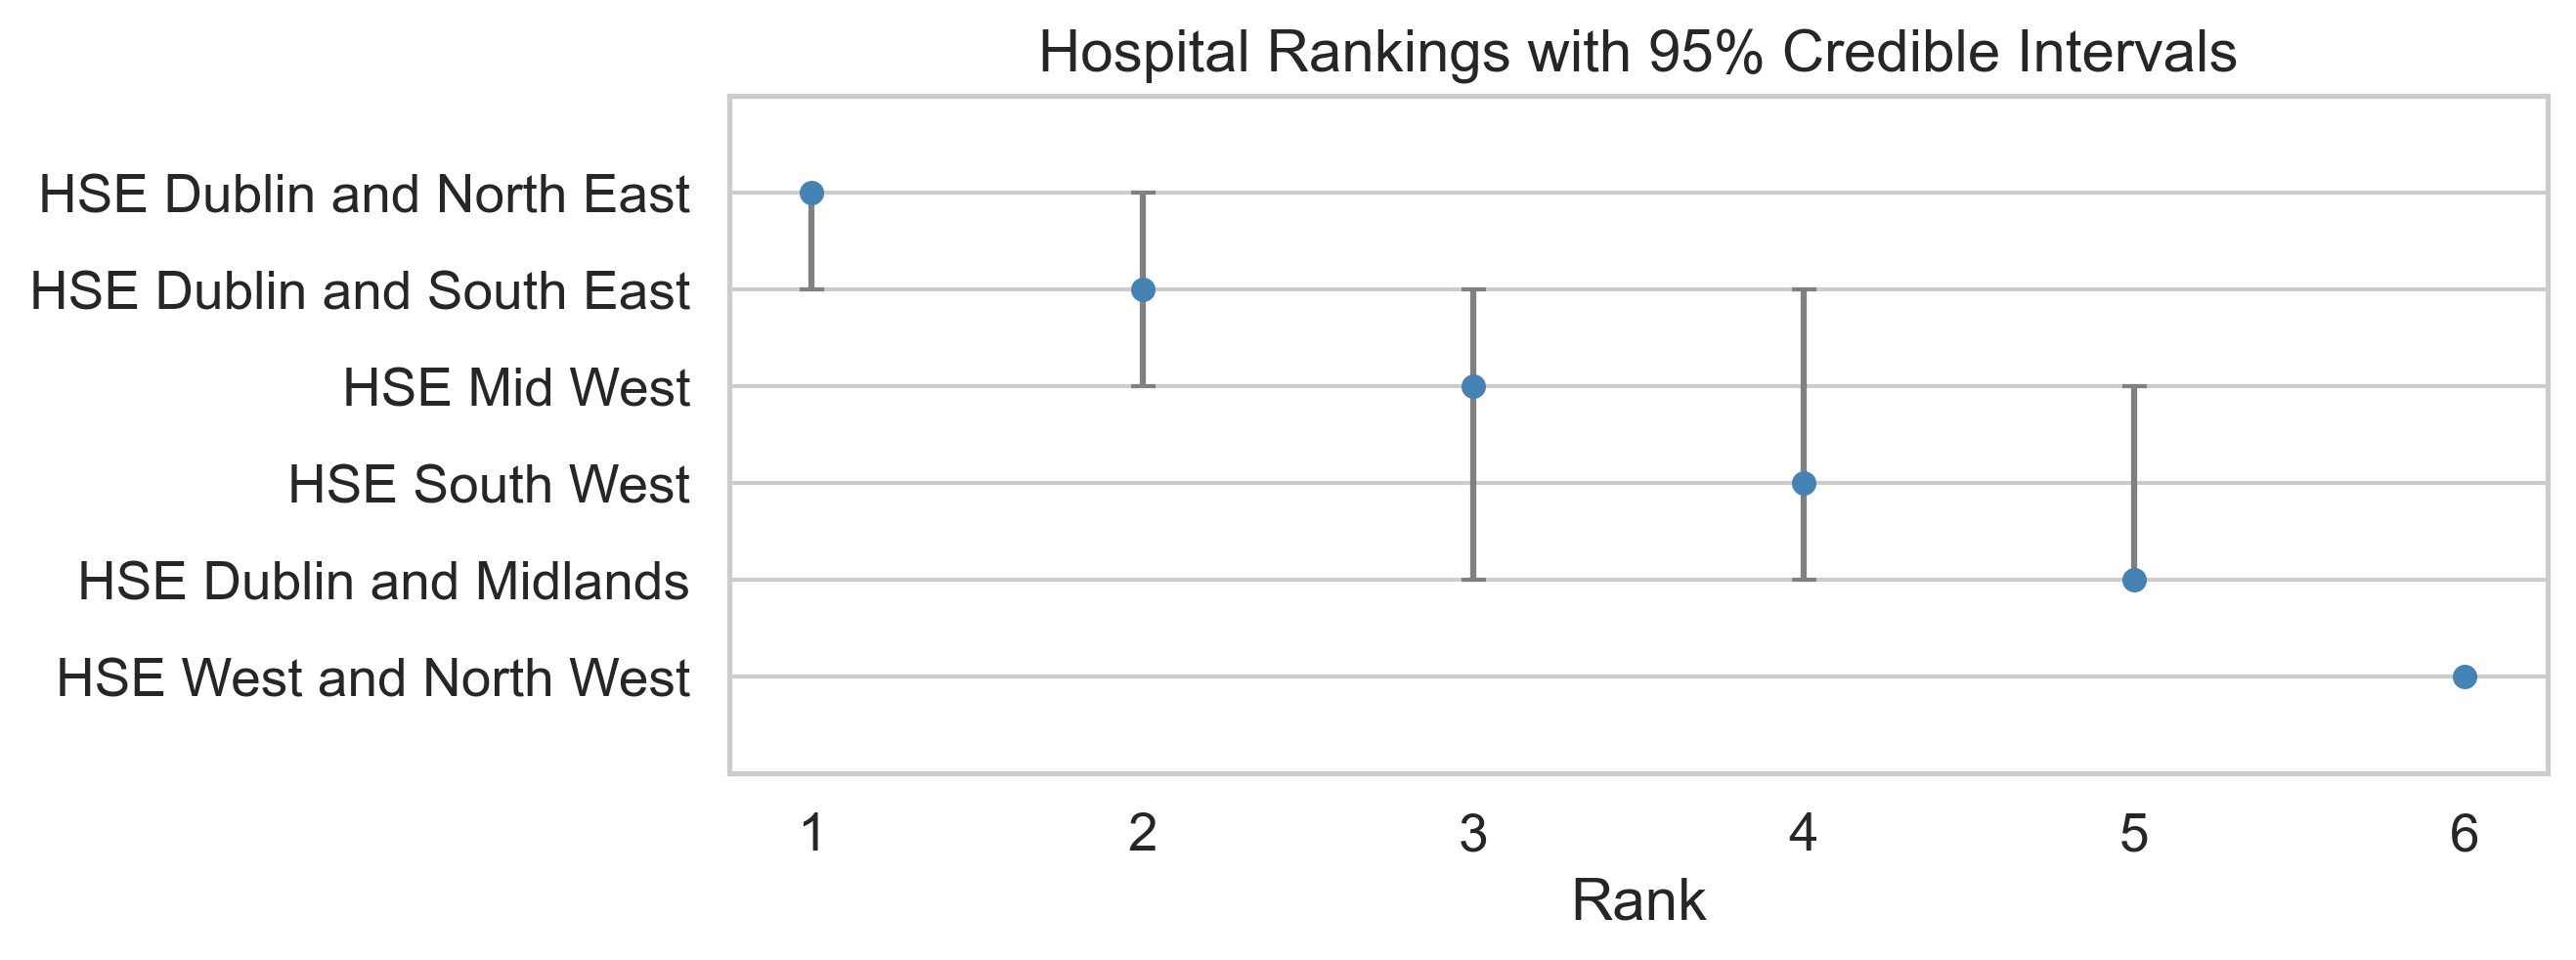

In [37]:
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
x_pos = range(len(final_ranked_df))
means = final_ranked_df['Rank mean']
lower_err = means - final_ranked_df['2.5%']                                                                
upper_err = final_ranked_df['97.5%'] - means

ax.errorbar(x_pos, means, yerr=[lower_err, upper_err],
              fmt='o', color='steelblue', ecolor='grey',
              elinewidth=1.5, capsize=3, markersize=5)

labels =  [''] + list(final_ranked_df.index)   
ax.xaxis.grid(False)                                                          
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)  
ax.set_xticklabels(range(0,7))
ax.set_ylim(0,7)
ax.set_xlabel('Rank')
ax.set_title('Hospital Rankings with 95% Credible Intervals')
ax.invert_yaxis()
plt.show()